<div align = "center">
    <h1>Crime Dataset Exploratory Analysis</h1>   
</div>

Import necessary libraries:

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Import the cleaned crime data file:

In [17]:
df = pd.read_csv("CLEANED-regional_forces_crime_data_2024-2025.csv")

Inspect the first five rows of the dataframe:

In [18]:
df.head()

,Unnamed: 0,Financial Year,Financial Quarter,Force Name,Offence Description,Offence Group,Offence Subgroup,Offence Code,Number of Offences,ITL1 region,ITL2 region
0,0,2024/25,1,Avon and Somerset,Absconding from lawful custody,Miscellaneous crimes against society,Miscellaneous crimes against society,80,2,South West (England),"['West of England', 'North Somerset, Somerset ..."
1,1,2024/25,1,Avon and Somerset,Abuse of children through sexual exploitation,Sexual offences,Other sexual offences,71,4,South West (England),"['West of England', 'North Somerset, Somerset ..."
2,2,2024/25,1,Avon and Somerset,Abuse of position of trust of a sexual nature,Sexual offences,Other sexual offences,73,1,South West (England),"['West of England', 'North Somerset, Somerset ..."
3,3,2024/25,1,Avon and Somerset,Aggravated burglary - residential (home),Theft offences,Residential burglary,29B,26,South West (England),"['West of England', 'North Somerset, Somerset ..."
4,4,2024/25,1,Avon and Somerset,Aggravated burglary - residential (unconnected...,Theft offences,Residential burglary,29C,1,South West (England),"['West of England', 'North Somerset, Somerset ..."


Inspect the shape of the dataframe:

In [19]:
df.shape

(22464, 11)

Get a summary of the dataframe:

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22464 entries, 0 to 22463
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Unnamed: 0           22464 non-null  int64
 1   Financial Year       22464 non-null  str  
 2   Financial Quarter    22464 non-null  int64
 3   Force Name           22464 non-null  str  
 4   Offence Description  22464 non-null  str  
 5   Offence Group        22464 non-null  str  
 6   Offence Subgroup     22464 non-null  str  
 7   Offence Code         22464 non-null  str  
 8   Number of Offences   22464 non-null  int64
 9   ITL1 region          22464 non-null  str  
 10  ITL2 region          22464 non-null  str  
dtypes: int64(3), str(8)
memory usage: 1.9 MB


Generate a statistical summary of the dataframe columns:

In [21]:
df.describe()

,Unnamed: 0,Financial Quarter,Number of Offences
count,22464.000000,22464.000000,22464.000000
mean,11231.500000,2.500000,221.086138
std,6484.942559,1.118059,936.850768
min,0.000000,1.000000,0.000000
25%,5615.750000,1.750000,0.000000
50%,11231.500000,2.500000,13.000000
75%,16847.250000,3.250000,110.250000
max,22463.000000,4.000000,29731.000000


Though this data has been cleaned by a teammate, it is wise to check for missing or duplicated data. First, we'll check for any missing values across the dataframe:

In [22]:
df.isnull().sum()

Unnamed: 0             0
Financial Year         0
Financial Quarter      0
Force Name             0
Offence Description    0
Offence Group          0
Offence Subgroup       0
Offence Code           0
Number of Offences     0
ITL1 region            0
ITL2 region            0
dtype: int64

Check for any duplicated data in the dataframe:

In [23]:
df.duplicated().sum()

np.int64(0)

Get on overview of the areas we have for analysis:

In [24]:
df.nunique()

Unnamed: 0             22464
Financial Year             1
Financial Quarter          4
Force Name                39
Offence Description      144
Offence Group              9
Offence Subgroup          25
Offence Code             144
Number of Offences      1807
ITL1 region                9
ITL2 region               33
dtype: int64

We can see from running df.unique() that the dataset containes crime records from **39 police forces** across **9 ITL1 regions and 33 ITL2 regions in England**. Crime offences are categorised using a hierarchy of **9 offence groups, 25 offence subgroups and 144 offence descriptions**.

As the dataset contains 144 individual offence descriptions, analysis will primarily focus on offence groups and offence subgroups. This allows broader crime patterns to be identified without introducing excessive complexity.

**ITL Regions**
- **ITL1**: ITL1 represents the broadest regioal level within England. Examples include 'London', 'West Midlands', and 'North West England'.
- **ITL2**: ITL2 regions are subregions **within** an ITL1 region. For example, in the ITL1 region of London, ITL2 regions include 'Inner London - West' and 'Outer London - South'.

The dataset has several categories for offence categorisation:
- **Offence Group**: Gives a broad classification and represents major categories of crime. For example, 'Burglary' covers all burglary-related offences.
- **Offence Subgroup**: Provides more detail for a crime within an offence group. For example, 'Residential Burglary' and 'Non-Residential Burglary'. 
- **Offence Description**: Gives the most detailed description of an offence. For example, within the offence group of Burglary, and the subgroup of Residential Burglary, the description specifies the exact offence recorded, such as 'Burglary in a Dwelling'. 
- **Offence Code**: The offence code corresponds to the offence description. I believe they are used for administrative purposes within the police force. 

## Crime by ITL1 region:

Let's take a look at the raw data before creating the chart.

In [25]:
crime_by_region = (
    df.groupby("ITL1 region")["Number of Offences"]
      .sum()
      .sort_values(ascending=False)
)

crime_by_region

ITL1 region
London                      953103
North West (England)        698039
South East (England)        624439
Yorkshire and The Humber    563303
West Midlands               515180
South West (England)        500612
East (England)              450512
East Midlands               392047
North East (England)        269244
Name: Number of Offences, dtype: int64

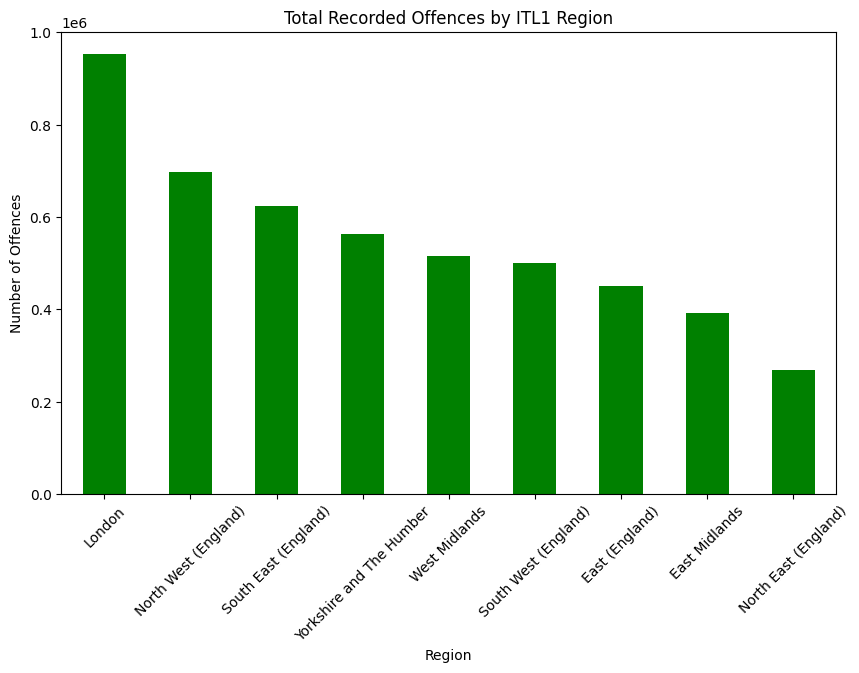

In [26]:
plt.figure(figsize=(10,6))

crime_by_region.plot(kind="bar", color="green")

plt.title("Total Recorded Offences by ITL1 Region")
plt.xlabel("Region")
plt.ylabel("Number of Offences")
plt.xticks(rotation=45)

plt.show()

The chart above illustrates, in descending order, the total number of recorded offences across England's nine ITL1 regions during the 2024/25 financial year. The 1 at the top of the y-axis is 1,000,000. We can see that London recorded the highest number of offences, and the North East of England the lowest. It should be noted the higher numbers may be due to a larger population in the area rather than higher crime rates.

## Crime by Offence Group

In [27]:
crime_by_group = (
    df.groupby("Offence Group")["Number of Offences"]
      .sum()
      .sort_values(ascending=False)
)

crime_by_group

Offence Group
Violence against the person             1816176
Theft offences                          1675059
Criminal damage and arson                428544
Public order offences                    410544
Sexual offences                          196184
Drug offences                            193122
Miscellaneous crimes against society     115846
Robbery                                   76540
Possession of weapons offences            54464
Name: Number of Offences, dtype: int64

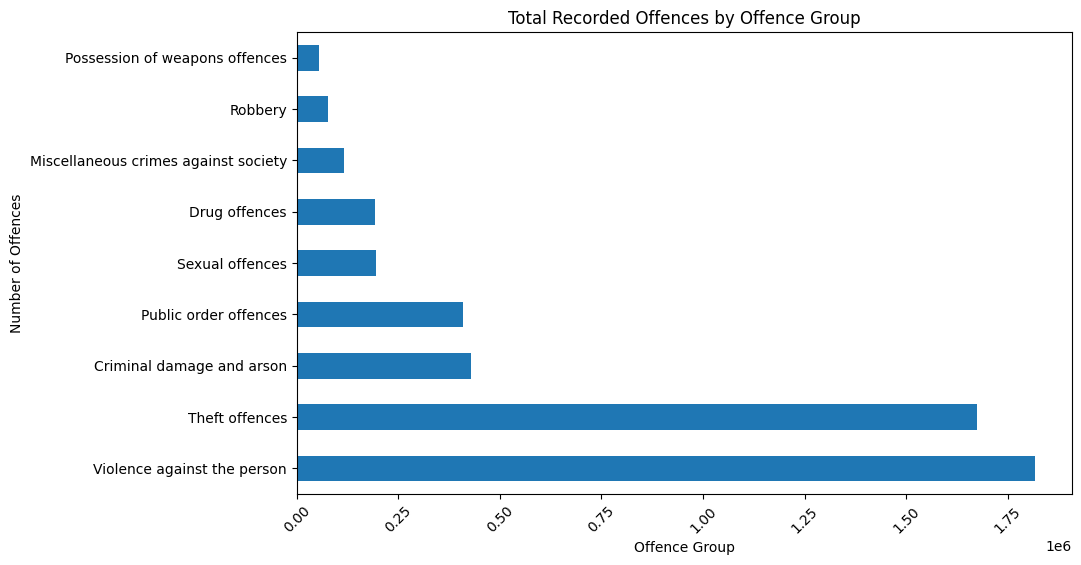

In [28]:
plt.figure(figsize=(10,6))

crime_by_group.plot.barh()

plt.title("Total Recorded Offences by Offence Group")
plt.xlabel("Offence Group")
plt.ylabel("Number of Offences")
plt.xticks(rotation=45)

plt.show()

The chart shows the total number of recorded offences for each offence group across England during 2024/25.

The chart shows that Violence against the person was the most frequently recorded offence group, recording 1.8 million offences. This is closely followed by Theft Offences, with that offence group being recorded close to 1.7 million times.

There is a notable drop after these first two categories, with Criminal Damage and Arson and Public Order Offences representing the next most common offence groups. At the lower end of the chart, Posession of Weapons Offences were among the least frequently recorded.

These findings suggest that overall crime levels are driven primarily by offences relating to violence and theft.


## Crime by Police Force

In [29]:
crime_by_force = (
    df.groupby("Force Name")["Number of Offences"]
      .sum()
      .sort_values(ascending=False)
)

crime_by_force.head(10)

Force Name
Metropolitan Police    943924
Greater Manchester     318679
West Midlands          308491
West Yorkshire         275196
Thames Valley          172209
Avon and Somerset      168349
Kent                   162059
Hampshire              154879
South Yorkshire        149368
Essex                  144423
Name: Number of Offences, dtype: int64

## Top Offence Subgroups

In [30]:
crime_by_subgroup = (
    df.groupby("Offence Subgroup")["Number of Offences"]
      .sum()
      .sort_values(ascending=False)
)

crime_by_subgroup.head(10)

Offence Subgroup
Violence without injury    766160
Stalking and harassment    558451
Shoplifting                500896
Violence with injury       488926
Other theft offences       412159
Public order offences      410544
Criminal damage            407228
Vehicle offences           336960
Residential burglary       160438
Theft from the person      135832
Name: Number of Offences, dtype: int64

In [31]:
df[
    ["Offence Group", "Offence Subgroup"]
].drop_duplicates().sort_values(
    ["Offence Group", "Offence Subgroup"]
).reset_index(drop=True)

,Offence Group,Offence Subgroup
0,Criminal damage and arson,Arson
1,Criminal damage and arson,Criminal damage
2,Drug offences,Possession of drugs
3,Drug offences,Trafficking of drugs
4,Miscellaneous crimes against society,Miscellaneous crimes against society
5,Possession of weapons offences,Possession of weapons offences
6,Public order offences,Public order offences
7,Robbery,Robbery of business property
8,Robbery,Robbery of personal property
9,Sexual offences,Other sexual offences


## Most reported crimes in the London region:

In [35]:
london_subgroups = (
    df[df["ITL1 region"] == "London"]
    .groupby("Offence Subgroup")["Number of Offences"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

london_subgroups

Offence Subgroup
Violence without injury    115658
Other theft offences       111689
Theft from the person      103884
Vehicle offences            98696
Shoplifting                 95121
Violence with injury        65328
Public order offences       56829
Stalking and harassment     55574
Criminal damage             54380
Residential burglary        34337
Name: Number of Offences, dtype: int64

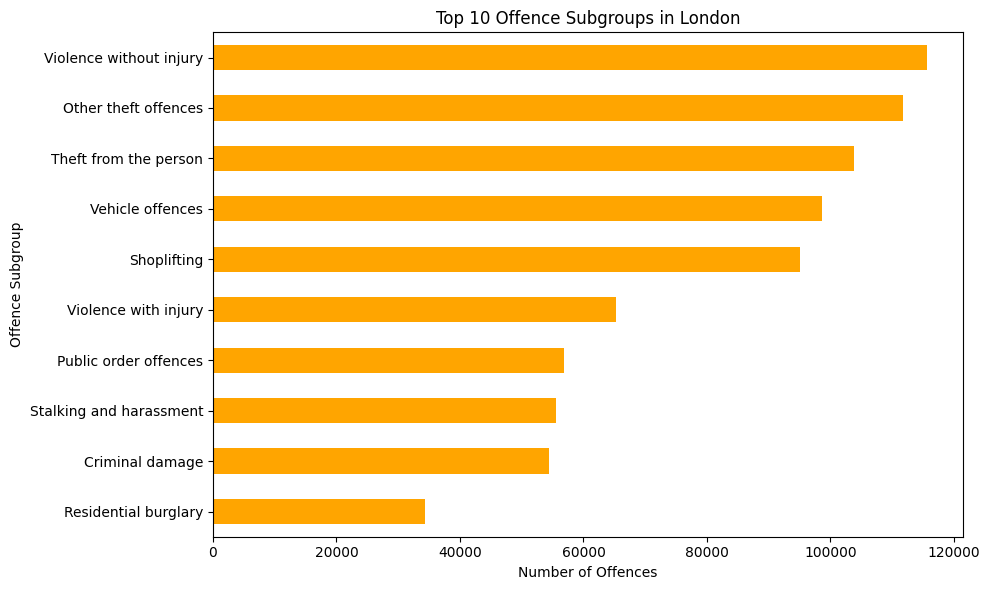

In [36]:
plt.figure(figsize=(10,6))

london_subgroups.sort_values().plot(kind="barh", color="orange")

plt.title("Top 10 Offence Subgroups in London")
plt.xlabel("Number of Offences")
plt.ylabel("Offence Subgroup")

plt.tight_layout()

plt.show()

## Top Three Reported Offence Subgroups by ITL Region

In [34]:
top5_by_region = (
    df.groupby(
        ["ITL1 region", "Offence Subgroup"]
    )["Number of Offences"]
    .sum()
    .reset_index()
)

top5_by_region = (
    top5_by_region
    .sort_values(
        ["ITL1 region", "Number of Offences"],
        ascending=[True, False]
    )
    .groupby("ITL1 region")
    .head(3)
)

top5_by_region

,ITL1 region,Offence Subgroup,Number of Offences
24,East (England),Violence without injury,79104
18,East (England),Shoplifting,48599
19,East (England),Stalking and harassment,47497
49,East Midlands,Violence without injury,56527
44,East Midlands,Stalking and harassment,47743
48,East Midlands,Violence with injury,45608
74,London,Violence without injury,115658
60,London,Other theft offences,111689
70,London,Theft from the person,103884
99,North East (England),Violence without injury,37440
